In [1]:
import os

# Change this to the ABSOLUTE PATH to the demo/ folder so you can correctly access data/ and params/
work_dir = "../"  # Leave this as-is if you're running the notebook from the `ptyrad/demo/scripts/` folder, this will change it back to demo/

os.chdir(work_dir)
print("Current working dir: ", os.getcwd())
# The printed working dir should be ".../ptyrad/demo" to locate the demo params files easily
# Note that the output/ directory will be automatically generated under your working directory

Current working dir:  /home/dnz75396/ptyrad/demo


In [2]:
import torch

from ptyrad.load import load_params
from ptyrad.split import generate_frc_splits
from ptyrad.utils import CustomLogger, print_system_info, set_gpu_device

logger = CustomLogger(
    log_file="ptyrad_log.txt", log_dir="auto", prefix_time="datetime", show_timestamp=True
)

# All the following params files are provided in demo/params/ and we're using relative path here
# So if you change the working directory, or have moved params files around, you'll have to provide absolute path to the params file

# params_path = "params/tBL_WSe2_reconstruct_minimal.yml"
params_path = "params/tBL_WSe2_reconstruct.yml"
# params_path = "params/PSO_reconstruct.yml"
# params_path = "params/tBL_WSe2_hypertune.yml" # This will run PtyRAD with the hyperparameter tuning mode

print_system_info()

# We enable validation to auto-fill defaults and check parameter consistency since PtyRAD 0.1.0b8
# If you run into issues with validation (e.g., false positives or unexpected errors),
# you can temporarily disable it by setting `validate=False` and prepare a fully complete params file yourself.
# If this happens, please report the bug so we can improve the validation logic.
params = load_params(params_path, validate=True)

print("Loaded params: ", params)
device = set_gpu_device(
    gpuid=0
)  # Pass in `gpuid = None` if you don't have access to a CUDA-compatible GPU. Note that running PtyRAD with CPU would be much slower than on GPU.

2026-05-01 13:04:43,431 - ### PtyRAD Logger configuration ###
2026-05-01 13:04:43,432 - log_file       = 'ptyrad_log.txt'. If log_file = None, no log file will be created.
2026-05-01 13:04:43,433 - log_dir        = 'auto'. If log_dir = 'auto', then log will be saved to `output_path` or 'logs/'.
2026-05-01 13:04:43,433 - flush_file     = True. Automatically set to True if `log_file is not None`
2026-05-01 13:04:43,434 - prefix_time    = datetime. If true, preset strings ('date', 'time', 'datetime'), or a string of time format, a datetime str is prefixed to the `log_file`.
2026-05-01 13:04:43,434 - prefix_jobid   = '0'. If not 0, it'll be prefixed to the log file. This is used for hypertune mode with multiple GPUs.
2026-05-01 13:04:43,434 - append_to_file = True. If true, logs will be appended to the existing file. If false, the log file will be overwritten.
2026-05-01 13:04:43,435 - show_timestamp = True. If true, the printed information will contain a timestamp.
2026-05-01 13:04:43,435

Loaded params:  {'init_params': {'random_seed': None, 'probe_illum_type': 'electron', 'probe_kv': 80.0, 'probe_conv_angle': 24.9, 'probe_defocus': 0.0, 'probe_c3': 0.0, 'probe_c5': 0.0, 'beam_kev': None, 'probe_dRn': None, 'probe_Rn': None, 'probe_D_H': None, 'probe_D_FZP': None, 'probe_Ls': None, 'meas_Npix': 128, 'pos_N_scans': 16384, 'pos_N_scan_slow': 128, 'pos_N_scan_fast': 128, 'pos_scan_step_size': 0.429, 'meas_calibration': {'mode': 'fitRBF', 'value': None}, 'probe_pmode_max': 6, 'probe_pmode_init_pows': [0.02], 'obj_omode_max': 1, 'obj_omode_init_occu': {'occu_type': 'uniform', 'init_occu': None}, 'obj_Nlayer': 6, 'obj_slice_thickness': 2.0, 'meas_permute': None, 'meas_reshape': None, 'meas_flipT': [1, 0, 0], 'meas_crop': None, 'meas_pad': {'mode': None, 'padding_type': 'power', 'target_Npix': 256, 'value': 0.0, 'threshold': 70.0}, 'meas_resample': {'mode': None, 'scale_factors': [2.0, 2.0]}, 'meas_add_source_size': None, 'meas_add_detector_blur': None, 'meas_remove_neg_values

2026-05-01 13:04:43,845 - ### Loading params file ###


2026-05-01 13:04:43,904 - Success! Loaded .yml file path = params/tBL_WSe2_reconstruct.yml
2026-05-01 13:04:43,905 - validate = True: Filling defaults and validating the params file...
2026-05-01 13:04:43,907 - Success! Params file validated and defaults applied.
2026-05-01 13:04:43,907 -  
2026-05-01 13:04:43,908 - ### Preparing binomial data splits for FRC evaluation ###
2026-05-01 13:04:43,908 - Injected shape (16384, 128, 128) for .raw file loading.
2026-05-01 13:04:43,909 - Loading original data from data/tBL_WSe2/Panel_g-h_Themis/scan_x128_y128.raw...


### Starting Data Splitting Test ###
Using compute device: cuda
Loading parameters from params/tBL_WSe2_reconstruct.yml...


2026-05-01 13:04:44,201 - Success! Loaded .raw file path = data/tBL_WSe2/Panel_g-h_Themis/scan_x128_y128.raw
2026-05-01 13:04:44,202 - Imported .raw data shape = (16384, 128, 128)
2026-05-01 13:04:44,203 - Imported .raw data type = float32
2026-05-01 13:04:44,204 - Executing GPU-accelerated binomial split...
2026-05-01 13:04:44,542 - WARNING: Negative values found (min = -30.8785). Clipping to 0 to simulate physical electron counts.
2026-05-01 13:04:47,206 - Plotting example diffraction patterns from the splits for visual verification...


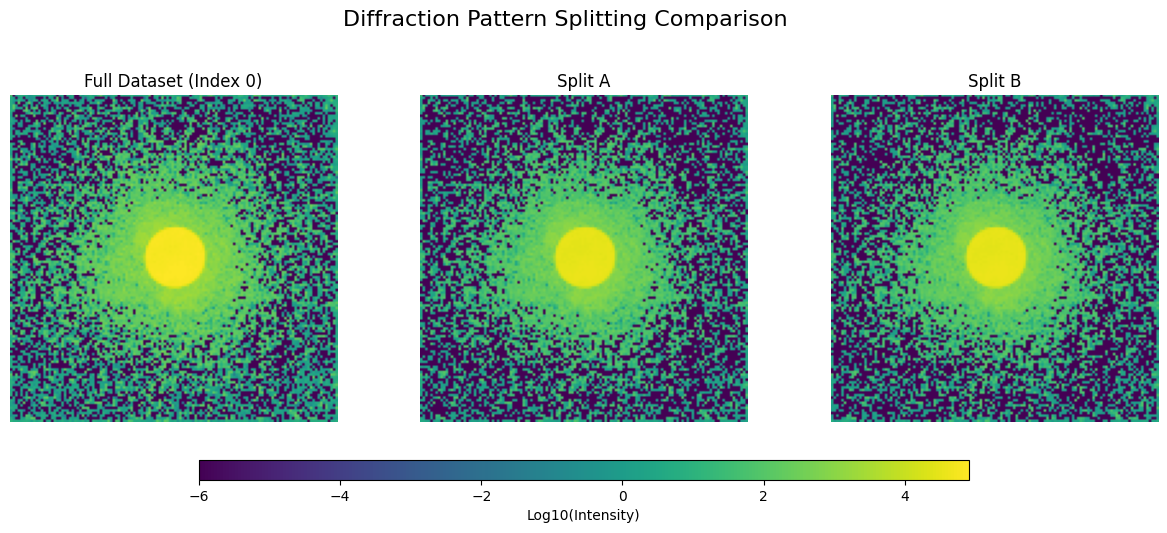

2026-05-01 13:04:47,542 - Saving splits to data/tBL_WSe2/Panel_g-h_Themis with extension .hdf5...
2026-05-01 13:05:36,137 - Splits successfully generated and saved.
2026-05-01 13:05:36,141 -  


('data/tBL_WSe2/Panel_g-h_Themis/scan_x128_y128_split1.hdf5',
 'data/tBL_WSe2/Panel_g-h_Themis/scan_x128_y128_split2.hdf5')

In [3]:
print("### Starting Data Splitting Test ###")

# 1. Setup Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using compute device: {device}")

# 2. Load Parameters
print(f"Loading parameters from {params_path}...")
params = load_params(params_path, validate=True)

generate_frc_splits(params, verbose=True, plot=True, device="cuda")